# Functions Demo (Standalone Mode)

## Table of Contents

1. [Creating Functions on Domains](#1-creating-functions-on-domains)
2. [Function Properties and Evaluation](#2-function-properties-and-evaluation)
3. [Function Integration](#3-function-integration)
4. [Weighted Integration](#4-weighted-integration)
5. [Functions with Compact Support](#5-functions-with-compact-support)
6. [Function Arithmetic](#6-function-arithmetic)
7. [Plotting Functions](#7-plotting-functions)
8. [Copying Functions](#8-copying-functions)
9. [Summary](#9-summary)

In [58]:
import numpy as np
import matplotlib.pyplot as plt

# Import from intervalinf
from intervalinf import IntervalDomain, Function

# Set up plotting
plt.style.use('seaborn-v0_8')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

## 1. Creating Functions on Domains

The simplest way to create a function: just pass a domain and a callable.

### Core API Usage:

In [59]:
# Create a domain
domain = IntervalDomain(0, 1, boundary_type='closed')

# Create a function on that domain
f = Function(domain, evaluate_callable=lambda x: x**2, name="f(x) = x²")

# Evaluate the function
f(0.5)  # Returns 0.25

# Check if attached to a space
f.is_attached  # Returns False (standalone mode)

False

In [60]:
# Create several example functions
domain = IntervalDomain(0, 2*np.pi, boundary_type='closed')

functions = [
    Function(domain, evaluate_callable=lambda x: np.sin(x), name="sin(x)"),
    Function(domain, evaluate_callable=lambda x: np.cos(x), name="cos(x)"),
    Function(domain, evaluate_callable=lambda x: x**2, name="x²"),
    Function(domain, evaluate_callable=lambda x: np.exp(-x), name="e^(-x)"),
]

print("Created Functions:")
print("="*50)
for func in functions:
    print(f"  {func.name:12s} - Domain: {func.function_domain}, Attached: {func.is_attached}")

# Evaluate at a point
x_test = np.pi / 2
print(f"\nEvaluation at x = π/2:")
for func in functions:
    value = func(x_test)
    print(f"  {func.name:12s}: {value:.6f}")

Created Functions:
  sin(x)       - Domain: [0.0, 6.283185307179586], Attached: False
  cos(x)       - Domain: [0.0, 6.283185307179586], Attached: False
  x²           - Domain: [0.0, 6.283185307179586], Attached: False
  e^(-x)       - Domain: [0.0, 6.283185307179586], Attached: False

Evaluation at x = π/2:
  sin(x)      : 1.000000
  cos(x)      : 0.000000
  x²          : 2.467401
  e^(-x)      : 0.207880


### Visualization:

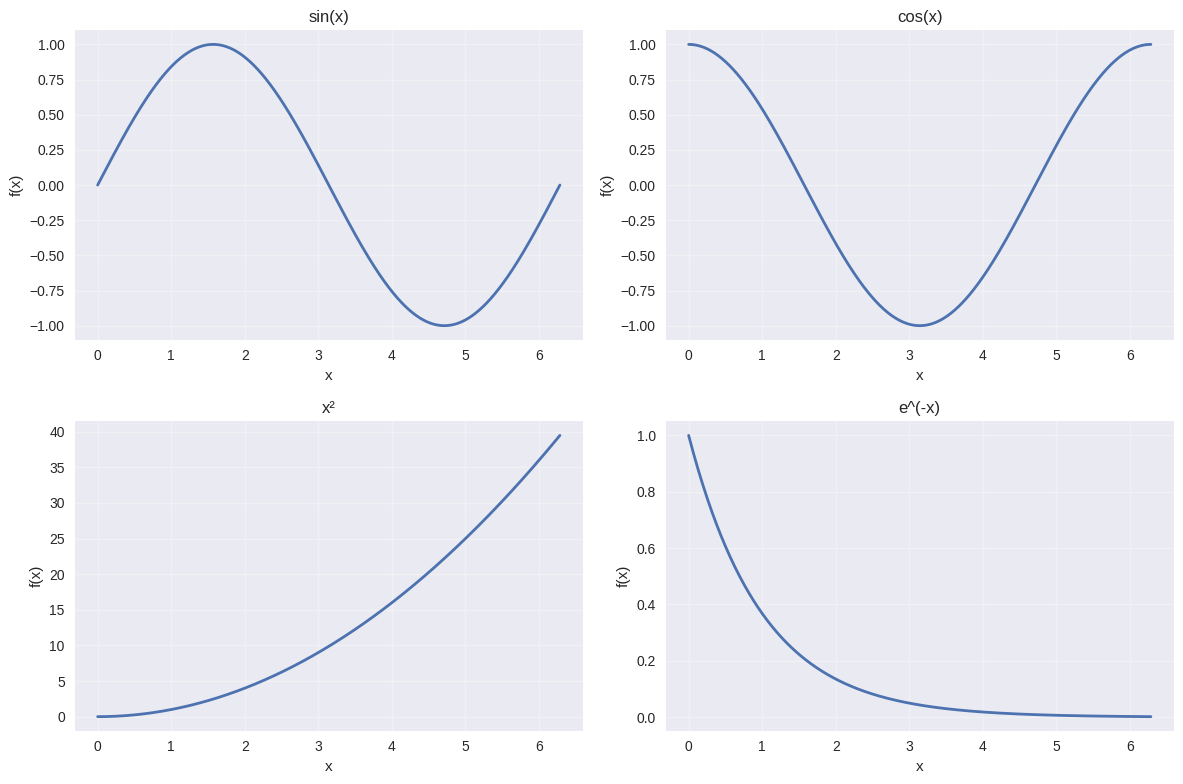

In [61]:
# Plot all functions
x = np.linspace(0, 2*np.pi, 500)

plt.figure(figsize=(12, 8))
for i, func in enumerate(functions):
    y = func(x)  # Can call function directly or use func.evaluate(x)
    plt.subplot(2, 2, i+1)
    plt.plot(x, y, linewidth=2)
    plt.xlabel('x')
    plt.ylabel('f(x)')
    plt.title(func.name)
    plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 2. Function Properties and Evaluation

Functions have several useful properties and evaluation methods.

### Core API Usage:

In [62]:
# Create a function
domain = IntervalDomain(-1, 1, boundary_type='closed')
f = Function(domain, evaluate_callable=lambda x: x**3 - x, name="x³ - x")

# Access properties
f.name                  # "x³ - x"
f.function_domain       # IntervalDomain(-1, 1)
f.is_attached          # False

# Evaluate at single point
f(0.5)

# Evaluate at array of points
x_array = np.array([0.0, 0.5, 1.0])
f(x_array)

array([ 0.   , -0.375,  0.   ])

### Detailed Examples:

Function Evaluation Methods:
Polynomial     : f(1.0) = 0.000000 (both methods equivalent: True)
Gaussian       : f(1.0) = 0.367879 (both methods equivalent: True)
Damped sine    : f(1.0) = -0.352769 (both methods equivalent: True)

Array Evaluation:
x values: [-2. -1.  0.  1.  2.]
Polynomial     : [-18.  -4.   0.   0.   2.]
Gaussian       : [0.01831564 0.36787944 1.         0.36787944 0.01831564]
Damped sine    : [ 0.07362525  0.35276853  0.         -0.35276853 -0.07362525]


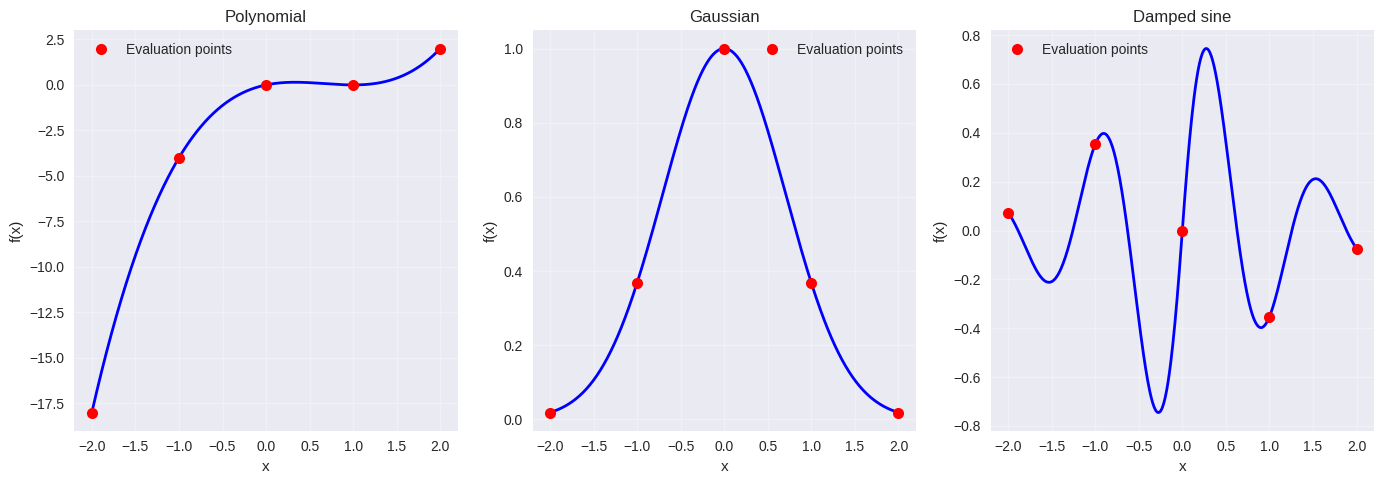

In [63]:
domain = IntervalDomain(-2, 2, boundary_type='closed')

# Different function types
polynomial = Function(domain, evaluate_callable=lambda x: x**3 - 2*x**2 + x, name="Polynomial")
exponential = Function(domain, evaluate_callable=lambda x: np.exp(-x**2), name="Gaussian")
oscillatory = Function(domain, evaluate_callable=lambda x: np.sin(5*x) * np.exp(-abs(x)), name="Damped sine")

functions = [polynomial, exponential, oscillatory]

# Demonstrate different evaluation methods
print("Function Evaluation Methods:")
print("="*60)

x_test = 1.0
for func in functions:
    # Method 1: Direct call (preferred)
    value1 = func(x_test)

    # Method 2: Explicit evaluate method
    value2 = func.evaluate(x_test)

    print(f"{func.name:15s}: f({x_test}) = {value1:.6f} (both methods equivalent: {np.isclose(value1, value2)})")

# Array evaluation
print("\nArray Evaluation:")
x_array = np.linspace(-2, 2, 5)
print(f"x values: {x_array}")
for func in functions:
    y_array = func(x_array)
    print(f"{func.name:15s}: {y_array}")

# Visualization
x_fine = np.linspace(-2, 2, 500)

plt.figure(figsize=(14, 5))
for i, func in enumerate(functions):
    plt.subplot(1, 3, i+1)
    y = func(x_fine)
    plt.plot(x_fine, y, 'b-', linewidth=2)

    # Mark evaluation points
    y_eval = func(x_array)
    plt.plot(x_array, y_eval, 'ro', markersize=8, label='Evaluation points')

    plt.xlabel('x')
    plt.ylabel('f(x)')
    plt.title(func.name)
    plt.grid(True, alpha=0.3)
    plt.legend()

plt.tight_layout()
plt.show()

## 3. Function Integration

Functions can be integrated over their domain using the `integrate()` method.

### Core API Usage:

In [64]:
# Create a function
domain = IntervalDomain(0, 1, boundary_type='closed')
f = Function(domain, evaluate_callable=lambda x: x**2, name="x²")

# Integrate over the domain
result = f.integrate()  # Uses Simpson's rule by default

# Specify integration method
result_trapz = f.integrate(method='trapz', n_points=1000)
result_adaptive = f.integrate(method='adaptive')

# Integration with weight function
result_weighted = f.integrate(weight=lambda x: np.exp(-x))

### Detailed Integration Examples:

In [65]:
# Test functions with known integrals
domain = IntervalDomain(0, 1, boundary_type='closed')

test_functions = {
    'x²': (lambda x: x**2, 1/3),
    'x³': (lambda x: x**3, 1/4),
    'sin(πx)': (lambda x: np.sin(np.pi * x), 2/np.pi),
    'e^x': (lambda x: np.exp(x), np.e - 1),
}

print("Integration Accuracy Test:")
print("="*80)
print(f"{'Function':15s} | {'Analytical':>12s} | {'Computed':>12s} | {'Error':>12s}")
print("-"*80)

for name, (func_def, analytical) in test_functions.items():
    f = Function(domain, evaluate_callable=func_def, name=name)
    computed = f.integrate(method='simpson', n_points=1000)
    error = abs(computed - analytical)

    print(f"{name:15s} | {analytical:12.6f} | {computed:12.6f} | {error:12.2e}")

# Test different integration methods
print("\nIntegration Method Comparison:")
print("="*80)
f = Function(domain, evaluate_callable=lambda x: np.sin(np.pi * x), name="sin(πx)")
analytical = 2/np.pi

methods = ['simpson', 'trapz', 'adaptive']
for method in methods:
    if method == 'adaptive':
        result = f.integrate(method=method)
    else:
        result = f.integrate(method=method, n_points=1000)
    error = abs(result - analytical)
    print(f"  {method:10s}: {result:.8f}  (error: {error:.2e})")

Integration Accuracy Test:
Function        |   Analytical |     Computed |        Error
--------------------------------------------------------------------------------
x²              |     0.333333 |     0.333333 |     0.00e+00
x³              |     0.250000 |     0.250000 |     2.51e-13
sin(πx)         |     0.636620 |     0.636620 |     1.64e-12
e^x             |     1.718282 |     1.718282 |     1.23e-13

Integration Method Comparison:
  simpson   : 0.63661977  (error: 1.64e-12)
  trapz     : 0.63661925  (error: 5.25e-07)
  adaptive  : 0.63661977  (error: 0.00e+00)


## 4. Weighted Integration

Functions can be integrated with weight functions: ∫ f(x) w(x) dx.

### Core API Usage:

In [66]:
# Create a function
domain = IntervalDomain(0, 1, boundary_type='closed')
f = Function(domain, evaluate_callable=lambda x: x**2)

# Integrate with weight
result = f.integrate(weight=lambda x: np.exp(-x))

# This computes: ∫₀¹ x² e^(-x) dx

### Visualization of Weighted Integration:

Weighted Integration:
Function: sin(πx)
Domain: [0.0, 2.0]

Results:
  w(x) = 1            : -0.000000
  w(x) = x            : -0.636620
  w(x) = e^(-x)       : 0.249910
  w(x) = 1/(1+x²)     : 0.303439


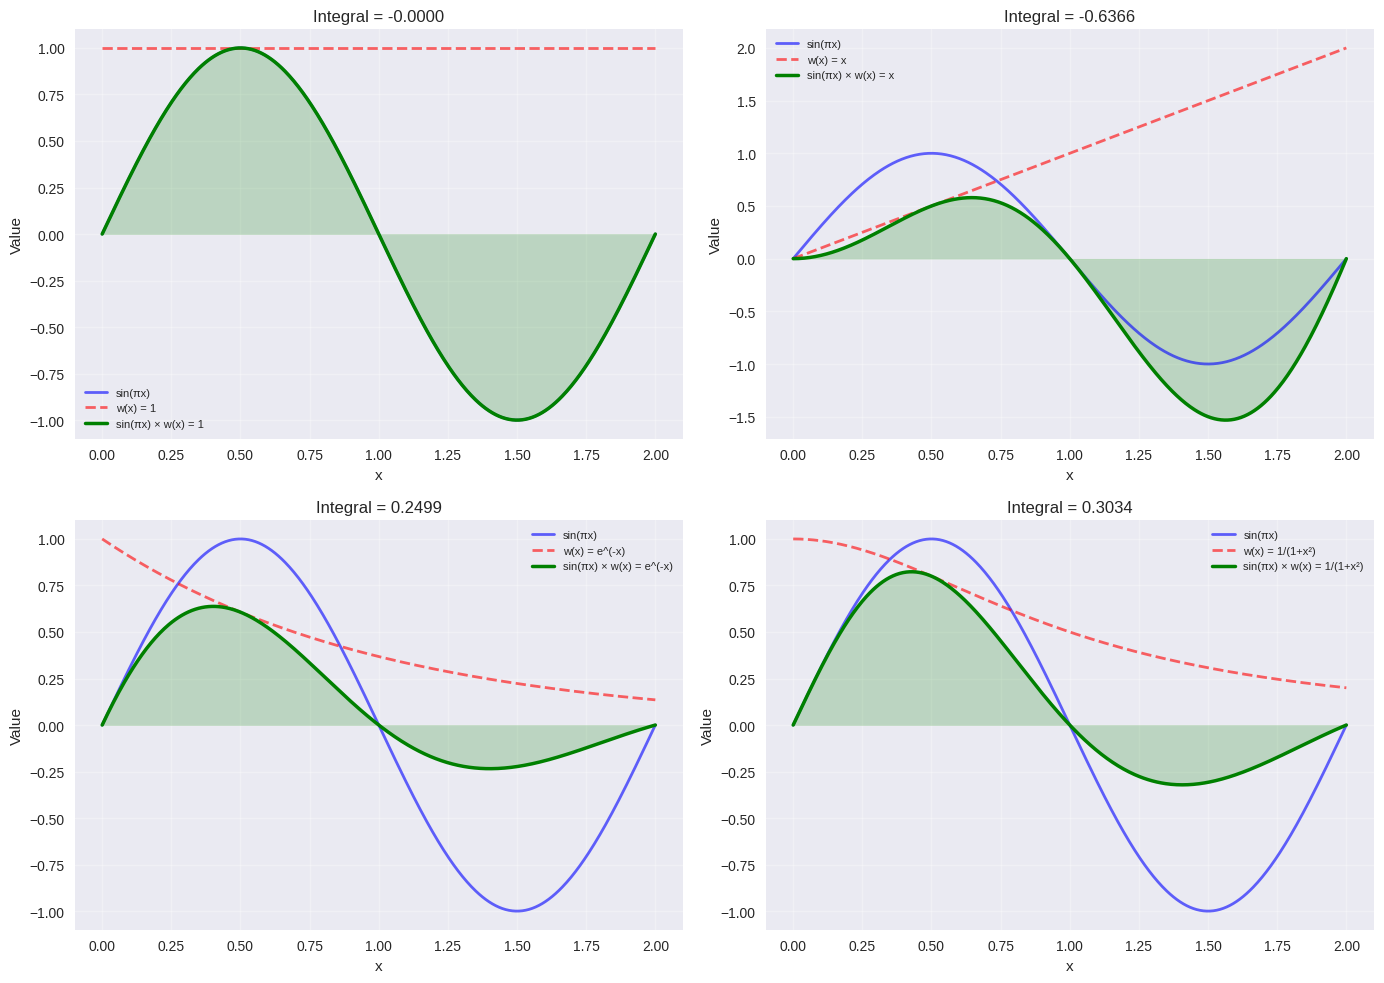

In [67]:
domain = IntervalDomain(0, 2, boundary_type='closed')

# Function to integrate
f = Function(domain, evaluate_callable=lambda x: np.sin(np.pi * x), name="sin(πx)")

# Different weight functions
weights = [
    (lambda x: np.ones_like(x), "w(x) = 1"),
    (lambda x: x, "w(x) = x"),
    (lambda x: np.exp(-x), "w(x) = e^(-x)"),
    (lambda x: 1 / (1 + x**2), "w(x) = 1/(1+x²)"),
]

print("Weighted Integration:")
print("="*60)
print(f"Function: {f.name}")
print(f"Domain: {domain}")
print("\nResults:")

x = np.linspace(0, 2, 500)
fx = f(x)

plt.figure(figsize=(14, 10))

for i, (weight, weight_name) in enumerate(weights):
    # Compute weighted integral
    result = f.integrate(weight=weight, method='simpson', n_points=1000)
    print(f"  {weight_name:20s}: {result:.6f}")

    # Plot
    plt.subplot(2, 2, i+1)

    wx = weight(x)
    integrand = fx * wx

    plt.plot(x, fx, 'b-', linewidth=2, label=f.name, alpha=0.6)
    plt.plot(x, wx, 'r--', linewidth=2, label=weight_name, alpha=0.6)
    plt.plot(x, integrand, 'g-', linewidth=2.5, label=f'{f.name} × {weight_name}')
    plt.fill_between(x, 0, integrand, alpha=0.2, color='green')

    plt.xlabel('x')
    plt.ylabel('Value')
    plt.title(f'Integral = {result:.4f}')
    plt.legend(fontsize=8)
    plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 5. Functions with Compact Support

Functions can have compact support (nonzero only on a subset of the domain).

### Core API Usage:

In [68]:
# Create a function with compact support
domain = IntervalDomain(0, 2, boundary_type='closed')

# Function is nonzero only on [0.5, 1.5]
f = Function(
    domain,
    evaluate_callable=lambda x: np.sin(np.pi * x),
    support=(0.5, 1.5),
    name="sin(πx) with support [0.5, 1.5]"
)

# Outside support, function returns 0
f(0.2)    # Returns 0.0
f(1.0)    # Returns sin(π)
f(1.8)    # Returns 0.0

# Check if function has compact support
f.has_compact_support  # Returns True

True

### Examples with Multiple Support Regions:

Functions with Compact Support:

Single support [0.5, 1.5]:
  Domain: [0.0, 3.0]
  Support: [(0.5, 1.5)]
  Has compact support: True
  Test evaluations:
    f(0.1) = 0.0000
    f(0.6) = 1.0000
    f(1.2) = 1.0000
    f(1.7) = 0.0000
    f(2.8) = 0.0000

Two disjoint supports:
  Domain: [0.0, 3.0]
  Support: [(0.2, 0.8), (1.5, 2.2)]
  Has compact support: True
  Test evaluations:
    f(0.1) = 0.0000
    f(0.6) = 0.9511
    f(1.2) = 0.0000
    f(1.7) = 0.5878
    f(2.8) = 0.0000

Three disjoint supports:
  Domain: [0.0, 3.0]
  Support: [(0.0, 0.5), (1.0, 1.5), (2.0, 2.5)]
  Has compact support: True
  Test evaluations:
    f(0.1) = 0.0100
    f(0.6) = 0.0000
    f(1.2) = 1.4400
    f(1.7) = 0.0000
    f(2.8) = 0.0000


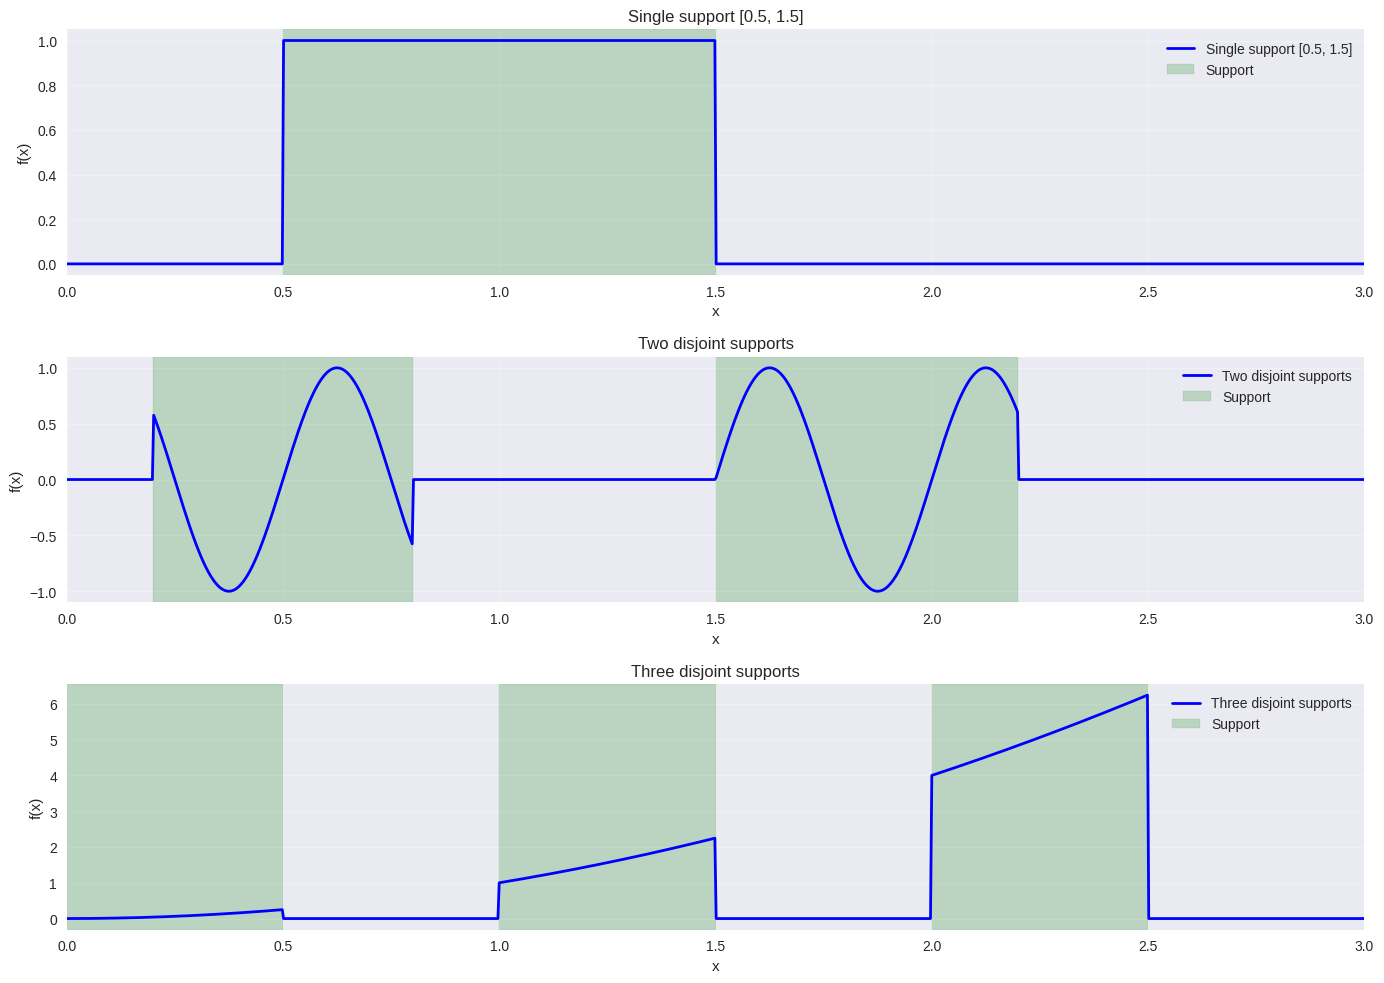

In [69]:
domain = IntervalDomain(0, 3, boundary_type='closed')

# Create functions with different support configurations
functions_with_support = [
    Function(
        domain,
        evaluate_callable=lambda x: np.ones_like(x),
        support=(0.5, 1.5),
        name="Single support [0.5, 1.5]"
    ),
    Function(
        domain,
        evaluate_callable=lambda x: np.sin(4*np.pi*x),
        support=[(0.2, 0.8), (1.5, 2.2)],
        name="Two disjoint supports"
    ),
    Function(
        domain,
        evaluate_callable=lambda x: x**2,
        support=[(0.0, 0.5), (1.0, 1.5), (2.0, 2.5)],
        name="Three disjoint supports"
    ),
]

print("Functions with Compact Support:")
print("="*60)
for func in functions_with_support:
    print(f"\n{func.name}:")
    print(f"  Domain: {func.function_domain}")
    print(f"  Support: {func.support}")
    print(f"  Has compact support: {func.has_compact_support}")

    # Test evaluation inside and outside support
    test_points = [0.1, 0.6, 1.2, 1.7, 2.8]
    print(f"  Test evaluations:")
    for x in test_points:
        y = func(x)
        print(f"    f({x:.1f}) = {y:.4f}")

# Visualize
x = np.linspace(0, 3, 1000)

plt.figure(figsize=(14, 10))

for i, func in enumerate(functions_with_support):
    plt.subplot(3, 1, i+1)

    y = func(x)
    plt.plot(x, y, 'b-', linewidth=2, label=func.name)

    # Highlight support regions
    for support_interval in func.support:
        a, b = support_interval
        plt.axvspan(a, b, alpha=0.2, color='green', label='Support' if support_interval == func.support[0] else '')

    plt.xlabel('x')
    plt.ylabel('f(x)')
    plt.title(func.name)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.xlim(0, 3)

plt.tight_layout()
plt.show()

### Why Compact Support Matters:

Compact support is primarily about **semantic clarity** and **automatic arithmetic handling**, not raw integration performance. When you specify support, you're telling the system "this function is mathematically zero outside these regions", which enables smart behavior in function arithmetic and ensures correctness.

The Value of Compact Support:

1. SEMANTIC CORRECTNESS:
------------------------------------------------------------
Evaluation at points: [1.0, 2.5, 5.0, 8.0]

Without support specification:
  f(1.0) = 0.135335
  f(2.5) = 0.882497
  f(5.0) = 0.135335
  f(8.0) = 0.000004
  ❌ Function evaluates to nonzero everywhere!

With support=(2, 4):
  f(1.0) = 0.000000
  f(2.5) = 0.882497
  f(5.0) = 0.000000
  f(8.0) = 0.000000
  ✓ Function is zero outside [2, 4] as intended!


2. INTEGRATION CORRECTNESS:
------------------------------------------------------------
With support: ∫ f(x)w(x) dx = 1.255737
  ✓ Integration automatically restricted to support [2, 4]

Without support: ∫ f(x)w(x) dx = 1.542847
  ⚠ Integrates over [0, 10], potentially incorrect!


3. MEMORY OF INTENT:
------------------------------------------------------------
f_with.has_compact_support:  True
f_with.support:              [(2, 4)]

✓ Support information is preserved
✓ Other parts of the code can query this
✓ Useful for F

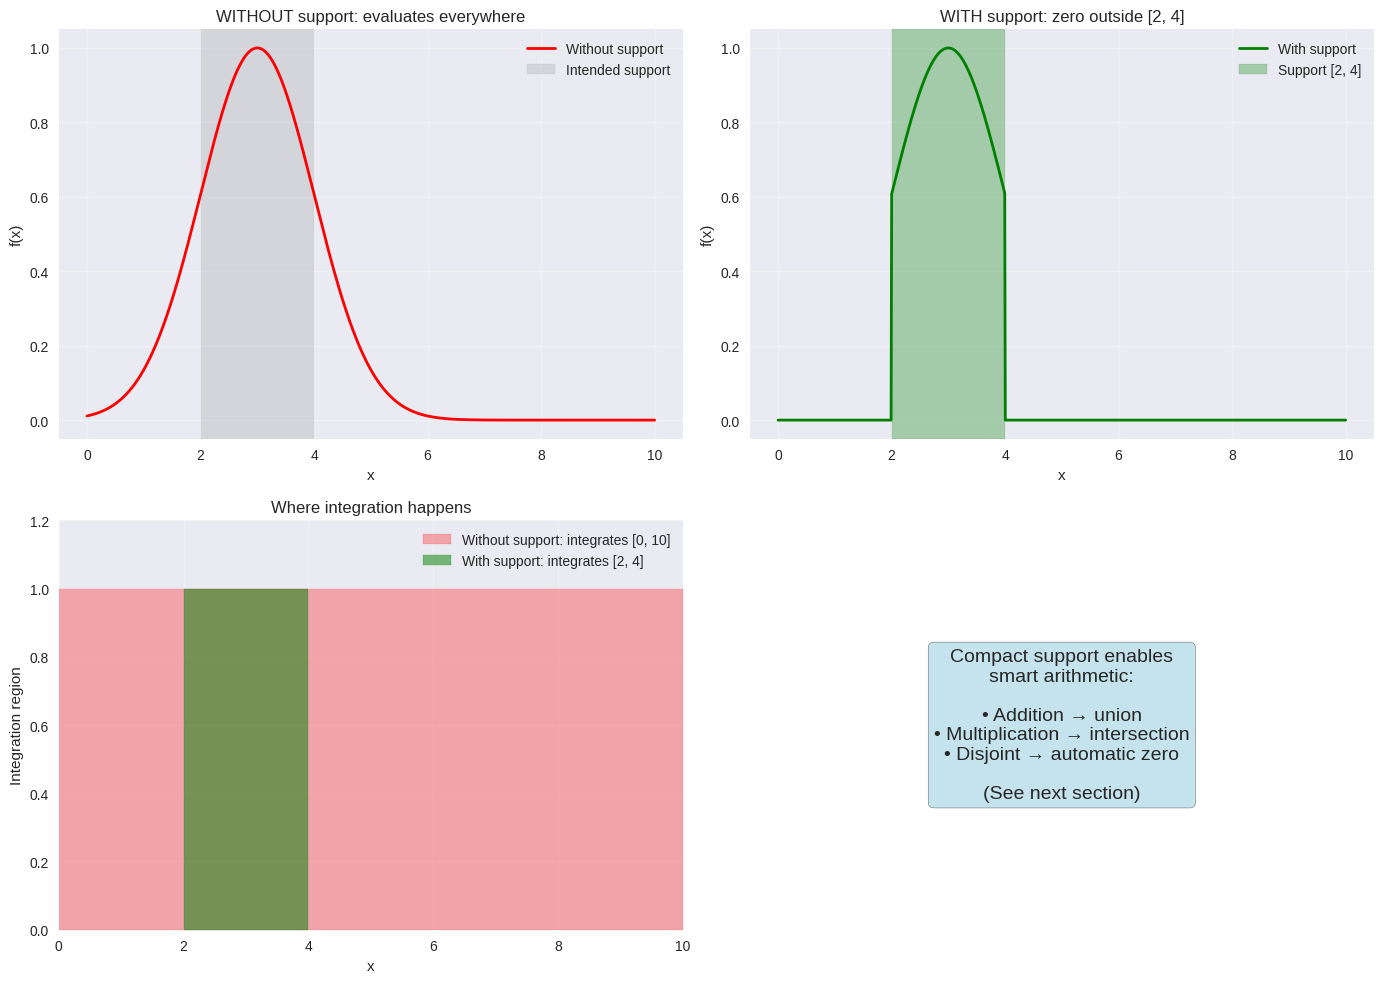


SUMMARY: Compact support is about correctness, not speed
✓ Documents mathematical intent
✓ Ensures evaluation is zero outside support
✓ Integration automatically restricted
✓ Enables smart arithmetic (next section)
✗ NOT primarily a performance optimization


In [ ]:
domain = IntervalDomain(0, 10, boundary_type='closed')

# Define a function that should be zero outside a region
def my_basis_function(x):
    """A smooth function we want to be zero outside [2, 4]."""
    return np.exp(-0.5 * (x - 3)**2)

# WITHOUT support: Function can be evaluated anywhere, misleading!
f_without = Function(
    domain,
    evaluate_callable=my_basis_function,
    name="Without support (incorrect!)"
)

# WITH support: Explicitly marks where function should be nonzero
f_with = Function(
    domain,
    evaluate_callable=my_basis_function,
    support=(2, 4),
    name="With support (correct!)"
)

print("The Value of Compact Support:")
print("="*60)
print("\n1. SEMANTIC CORRECTNESS:")
print("-" * 60)

# Test evaluation outside intended support
test_points = [1.0, 2.5, 5.0, 8.0]
print(f"Evaluation at points: {test_points}\n")

print("Without support specification:")
for x in test_points:
    print(f"  f({x:.1f}) = {f_without(x):.6f}")
print("  ❌ Function evaluates to nonzero everywhere!")
print()

print("With support=(2, 4):")
for x in test_points:
    print(f"  f({x:.1f}) = {f_with(x):.6f}")
print("  ✓ Function is zero outside [2, 4] as intended!")
print()

print("\n2. INTEGRATION CORRECTNESS:")
print("-" * 60)

# Create a weight function that's only defined on part of domain
def localized_weight(x):
    """Weight only makes sense on [1, 6]."""
    return np.where((x >= 1) & (x <= 6), 1 / (1 + (x - 3.5)**2), 0)

# With support, integration automatically restricted
integral_with = f_with.integrate(weight=localized_weight, n_points=1000)
print(f"With support: ∫ f(x)w(x) dx = {integral_with:.6f}")
print("  ✓ Integration automatically restricted to support [2, 4]")
print()

# Without support, we integrate over full domain
integral_without = f_without.integrate(weight=localized_weight, n_points=1000)
print(f"Without support: ∫ f(x)w(x) dx = {integral_without:.6f}")
print("  ⚠ Integrates over [0, 10], potentially incorrect!")
print()

print("\n3. MEMORY OF INTENT:")
print("-" * 60)
print(f"f_with.has_compact_support:  {f_with.has_compact_support}")
print(f"f_with.support:              {f_with.support}")
print("\n✓ Support information is preserved")
print("✓ Other parts of the code can query this")
print("✓ Useful for FEM, basis functions, sparse representations")

# Visualize the difference
x = np.linspace(0, 10, 1000)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: Without support
ax = axes[0, 0]
y = f_without(x)
ax.plot(x, y, 'r-', linewidth=2, label='Without support')
ax.axvspan(2, 4, alpha=0.2, color='gray', label='Intended support')
ax.set_xlabel('x')
ax.set_ylabel('f(x)')
ax.set_title('WITHOUT support: evaluates everywhere')
ax.legend()
ax.grid(True, alpha=0.3)

# Plot 2: With support
ax = axes[0, 1]
y = f_with(x)
ax.plot(x, y, 'g-', linewidth=2, label='With support')
ax.axvspan(2, 4, alpha=0.3, color='green', label='Support [2, 4]')
ax.set_xlabel('x')
ax.set_ylabel('f(x)')
ax.set_title('WITH support: zero outside [2, 4]')
ax.legend()
ax.grid(True, alpha=0.3)

# Plot 3: Integration regions comparison
ax = axes[1, 0]
ax.fill_between([0, 10], [0, 0], [1, 1], alpha=0.3, color='red', label='Without support: integrates [0, 10]')
ax.fill_between([2, 4], [0, 0], [1, 1], alpha=0.5, color='green', label='With support: integrates [2, 4]')
ax.set_xlim(0, 10)
ax.set_ylim(0, 1.2)
ax.set_xlabel('x')
ax.set_ylabel('Integration region')
ax.set_title('Where integration happens')
ax.legend()
ax.grid(True, alpha=0.3)

# Plot 4: Use in arithmetic (covered in next section)
ax = axes[1, 1]
ax.text(0.5, 0.5, 'Compact support enables\nsmart arithmetic:\n\n• Addition → union\n• Multiplication → intersection\n• Disjoint → automatic zero\n\n(See next section)',
        ha='center', va='center', fontsize=14,
        bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.7))
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.axis('off')

plt.tight_layout()
plt.show()

print("\n" + "="*60)
print("SUMMARY: Compact support is about correctness, not speed")
print("="*60)
print("✓ Documents mathematical intent")
print("✓ Ensures evaluation is zero outside support")
print("✓ Integration automatically restricted")
print("✓ Enables smart arithmetic (next section)")
print("✗ NOT primarily a performance optimization")

### How Arithmetic Operations Handle Support:

Function arithmetic operations are **support-aware**:

- **Addition/Subtraction**: Support is the **union** of individual supports (result is nonzero where either operand is nonzero)
- **Multiplication**: Support is the **intersection** of individual supports (result is only nonzero where *both* operands are nonzero)
- **Special optimization**: If supports are **disjoint** (don't overlap), multiplication returns a zero function immediately without computing anything!

Support-Aware Arithmetic:
f1 support: [(1, 3)]
f2 support: [(2, 4)]
f3 support: [(6, 8)]

f1 + f2 support (union):        [(1, 4)]
  Expected: [(1, 4)] ✓

f1 × f2 support (intersection): [(2, 3)]
  Expected: [(2, 3)] ✓

f1 × f3 support (disjoint):     None
  Supports don't overlap → zero function!
  Test: f1×f3(5.0) = 0.0000000000

2f1 + f2 - 0.5f3 support:       [(1, 4), (6, 8)]
  Union of all three supports ✓


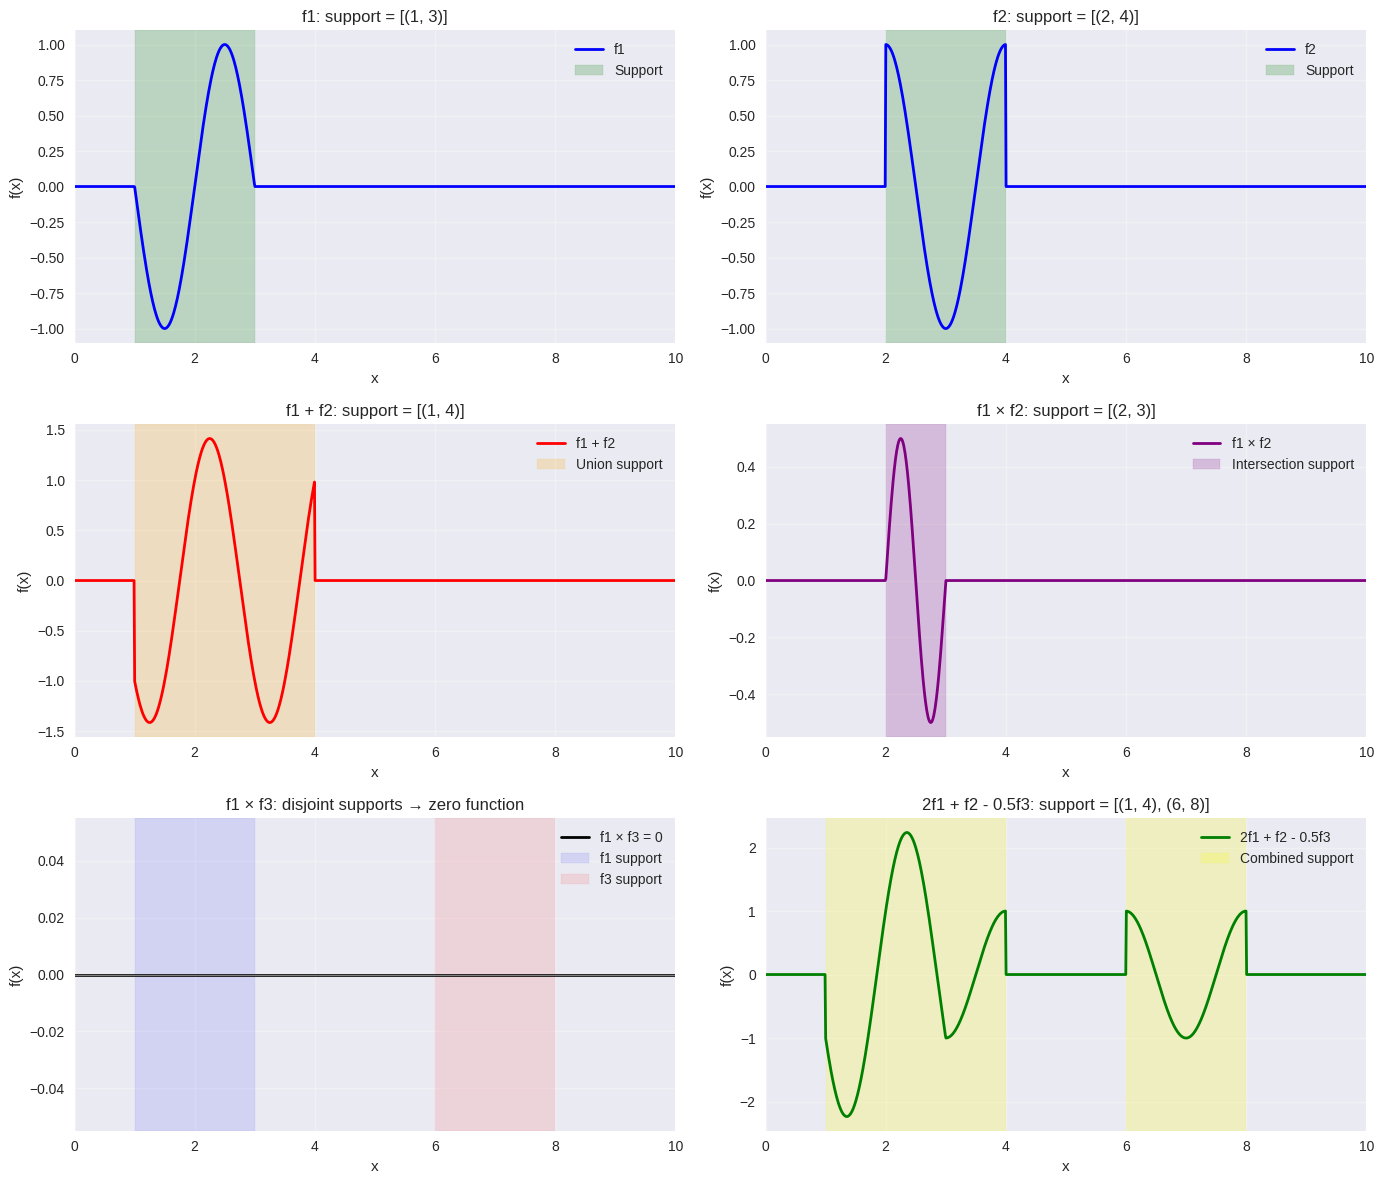


✓ Addition/subtraction: support = union (where ANY operand is nonzero)
✓ Multiplication: support = intersection (where ALL operands are nonzero)
✓ Disjoint supports: multiplication automatically returns zero function
✓ These optimizations make sparse function arithmetic very efficient!


In [77]:
domain = IntervalDomain(0, 10, boundary_type='closed')

# Create functions with different supports
f1 = Function(domain, evaluate_callable=lambda x: np.sin(np.pi*x),
              support=(1, 3), name="f1")
f2 = Function(domain, evaluate_callable=lambda x: np.cos(np.pi*x),
              support=(2, 4), name="f2")
f3 = Function(domain, evaluate_callable=lambda x: np.exp(-x),
              support=(6, 8), name="f3")

print("Support-Aware Arithmetic:")
print("="*60)
print(f"f1 support: {f1.support}")
print(f"f2 support: {f2.support}")
print(f"f3 support: {f3.support}")
print()

# Addition: union of supports
h_add = f1 + f2
print(f"f1 + f2 support (union):        {h_add.support}")
print(f"  Expected: [(1, 4)] ✓")
print()

# Multiplication: intersection of supports
h_mul = f1 * f2
print(f"f1 × f2 support (intersection): {h_mul.support}")
print(f"  Expected: [(2, 3)] ✓")
print()

# Disjoint supports → zero function
h_disjoint = f1 * f3
print(f"f1 × f3 support (disjoint):     {h_disjoint.support}")
print(f"  Supports don't overlap → zero function!")
print(f"  Test: f1×f3(5.0) = {h_disjoint(5.0):.10f}")
print()

# Complex expression
h_complex = 2*f1 + f2 - 0.5*f3
print(f"2f1 + f2 - 0.5f3 support:       {h_complex.support}")
print(f"  Union of all three supports ✓")

# Visualize
x = np.linspace(0, 10, 1000)

fig, axes = plt.subplots(3, 2, figsize=(14, 12))

# Original functions
for ax, func in zip(axes[0], [f1, f2, f3]):
    y = func(x)
    ax.plot(x, y, 'b-', linewidth=2, label=func.name)
    for a, b in func.support:
        ax.axvspan(a, b, alpha=0.2, color='green', label='Support' if (a,b) == func.support[0] else '')
    ax.set_xlabel('x')
    ax.set_ylabel('f(x)')
    ax.set_title(f'{func.name}: support = {func.support}')
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.set_xlim(0, 10)

# Addition
ax = axes[1, 0]
y = h_add(x)
ax.plot(x, y, 'r-', linewidth=2, label='f1 + f2')
for a, b in h_add.support:
    ax.axvspan(a, b, alpha=0.2, color='orange', label='Union support' if (a,b) == h_add.support[0] else '')
ax.set_xlabel('x')
ax.set_ylabel('f(x)')
ax.set_title(f'f1 + f2: support = {h_add.support}')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_xlim(0, 10)

# Multiplication (overlapping)
ax = axes[1, 1]
y = h_mul(x)
ax.plot(x, y, 'purple', linewidth=2, label='f1 × f2')
for a, b in h_mul.support:
    ax.axvspan(a, b, alpha=0.2, color='purple', label='Intersection support' if (a,b) == h_mul.support[0] else '')
ax.set_xlabel('x')
ax.set_ylabel('f(x)')
ax.set_title(f'f1 × f2: support = {h_mul.support}')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_xlim(0, 10)

# Multiplication (disjoint)
ax = axes[2, 0]
y = h_disjoint(x)
ax.plot(x, y, 'k-', linewidth=2, label='f1 × f3 = 0')
ax.axhline(0, color='gray', linewidth=1)
ax.axvspan(1, 3, alpha=0.1, color='blue', label='f1 support')
ax.axvspan(6, 8, alpha=0.1, color='red', label='f3 support')
ax.set_xlabel('x')
ax.set_ylabel('f(x)')
ax.set_title('f1 × f3: disjoint supports → zero function')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_xlim(0, 10)

# Complex expression
ax = axes[2, 1]
y = h_complex(x)
ax.plot(x, y, 'green', linewidth=2, label='2f1 + f2 - 0.5f3')
for a, b in h_complex.support:
    ax.axvspan(a, b, alpha=0.2, color='yellow', label='Combined support' if (a,b) == h_complex.support[0] else '')
ax.set_xlabel('x')
ax.set_ylabel('f(x)')
ax.set_title(f'2f1 + f2 - 0.5f3: support = {h_complex.support}')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_xlim(0, 10)

plt.tight_layout()
plt.show()

print("\n✓ Addition/subtraction: support = union (where ANY operand is nonzero)")
print("✓ Multiplication: support = intersection (where ALL operands are nonzero)")
print("✓ Disjoint supports: multiplication automatically returns zero function")
print("✓ These optimizations make sparse function arithmetic very efficient!")


## 6. Function Arithmetic

Functions support arithmetic operations: addition, subtraction, multiplication, and scalar operations.

### Core API Usage:

In [72]:
# Create functions
domain = IntervalDomain(0, 1, boundary_type='closed')
f = Function(domain, evaluate_callable=lambda x: x**2, name="x²")
g = Function(domain, evaluate_callable=lambda x: np.sin(np.pi * x), name="sin(πx)")

# Addition
h1 = f + g  # Creates new function: x² + sin(πx)

# Subtraction
h2 = f - g  # Creates new function: x² - sin(πx)

# Multiplication
h3 = f * g  # Creates new function: x² × sin(πx)

# Scalar multiplication
h4 = 2 * f  # Creates new function: 2x²
h5 = f * 3  # Creates new function: 3x²

# Scalar addition
h6 = f + 1  # Creates new function: x² + 1

### Detailed Arithmetic Examples:

Function Arithmetic:

Evaluation at x = 0.5:
  f(x)           : 0.250000
  g(x)           : -1.000000
  f + g          : -0.750000
  f - g          : 1.250000
  f × g          : -0.250000
  2f + 0.5g      : 0.000000


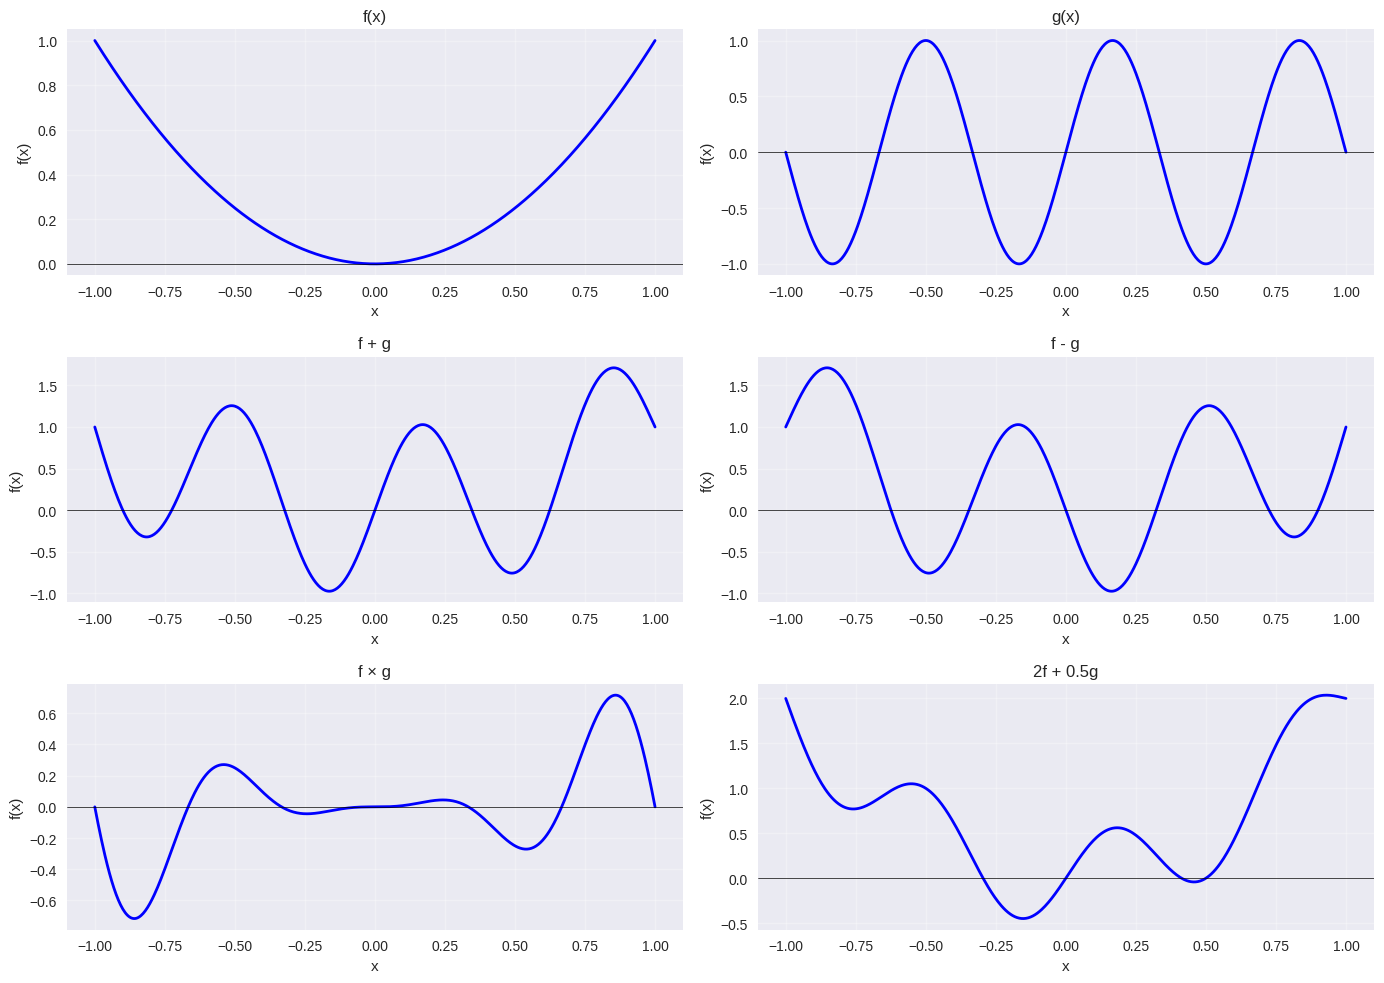


Integration of Combined Functions:
  ∫ (f(x)) dx = 0.666667
  ∫ (g(x)) dx = 0.000000
  ∫ (f + g) dx = 0.666667
  ∫ (f - g) dx = 0.666667
  ∫ (f × g) dx = 0.000000
  ∫ (2f + 0.5g) dx = 1.333333


In [73]:
domain = IntervalDomain(-1, 1, boundary_type='closed')

# Base functions
f = Function(domain, evaluate_callable=lambda x: x**2, name="f(x) = x²")
g = Function(domain, evaluate_callable=lambda x: np.sin(3*np.pi*x), name="g(x) = sin(3πx)")

# Create combinations
combinations = [
    (f, "f(x)"),
    (g, "g(x)"),
    (f + g, "f + g"),
    (f - g, "f - g"),
    (f * g, "f × g"),
    (2 * f + 0.5 * g, "2f + 0.5g"),
]

print("Function Arithmetic:")
print("="*60)

x_test = 0.5
print(f"\nEvaluation at x = {x_test}:")
for func, description in combinations:
    value = func(x_test)
    print(f"  {description:15s}: {value:.6f}")

# Visualize
x = np.linspace(-1, 1, 500)

plt.figure(figsize=(14, 10))

for i, (func, description) in enumerate(combinations):
    plt.subplot(3, 2, i+1)
    y = func(x)
    plt.plot(x, y, 'b-', linewidth=2)
    plt.xlabel('x')
    plt.ylabel('f(x)')
    plt.title(description)
    plt.grid(True, alpha=0.3)
    plt.axhline(0, color='k', linewidth=0.5)

plt.tight_layout()
plt.show()

# Integration of combined functions
print("\nIntegration of Combined Functions:")
print("="*60)
for func, description in combinations:
    integral = func.integrate(method='simpson', n_points=1000)
    print(f"  ∫ ({description}) dx = {integral:.6f}")

## 7. Plotting Functions

Functions have a built-in `plot()` method for quick visualization.

### Core API Usage:

<Axes: title={'center': 'Function on [0.0, 6.283185307179586]'}, xlabel='x', ylabel='f(x)'>

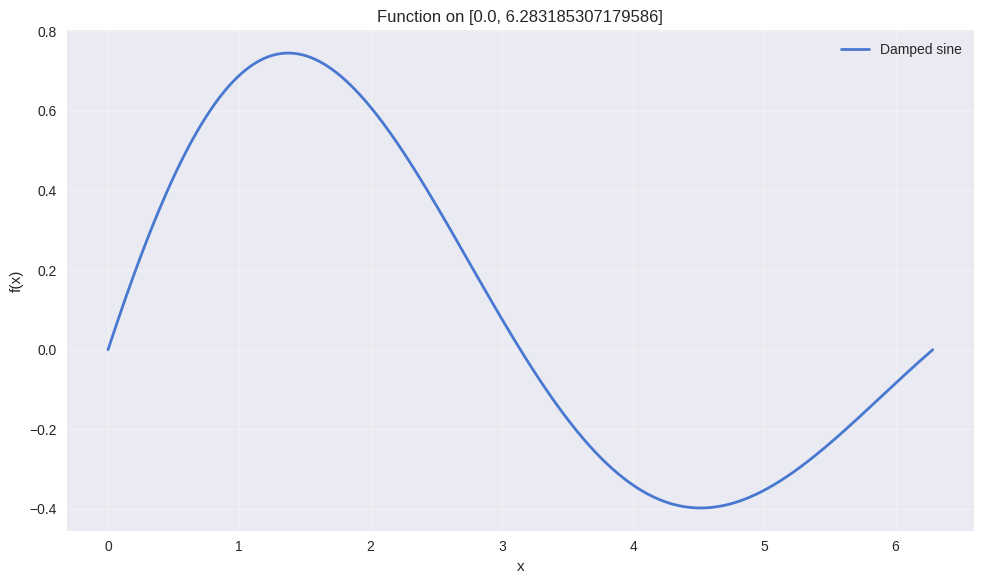

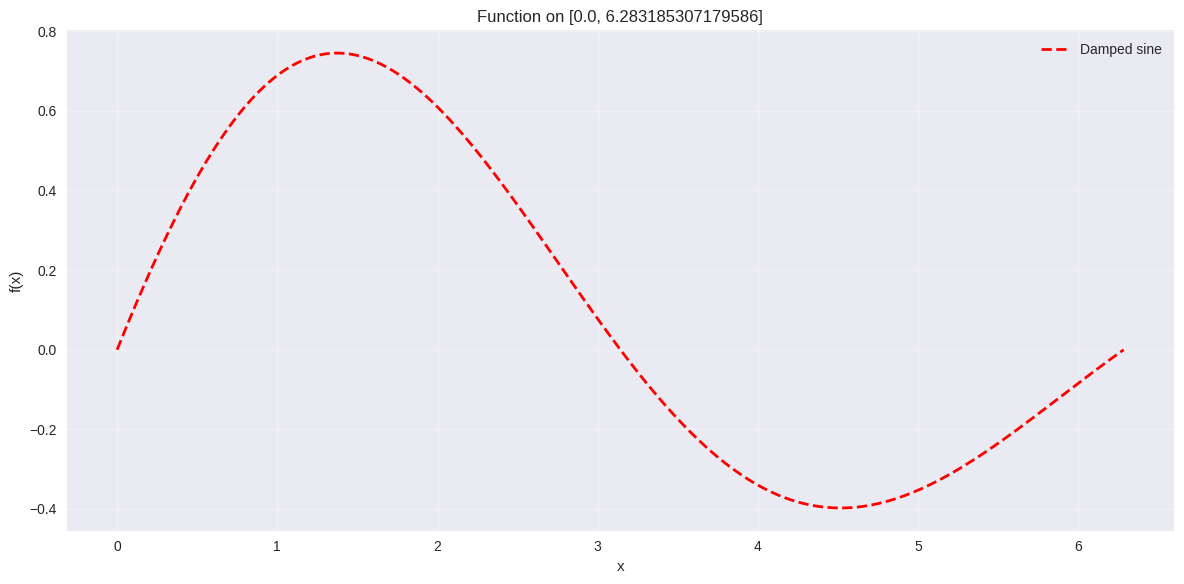

In [74]:
# Create a function
domain = IntervalDomain(0, 2*np.pi, boundary_type='closed')
f = Function(domain, evaluate_callable=lambda x: np.sin(x) * np.exp(-0.2*x), name="Damped sine")

# Simple plot
f.plot()

# Plot with custom settings
f.plot(n_points=500, figsize=(12, 6), color='red', linestyle='--')

### Multiple Function Plots:

Using built-in plot() method:
  Plotting sin(x)...


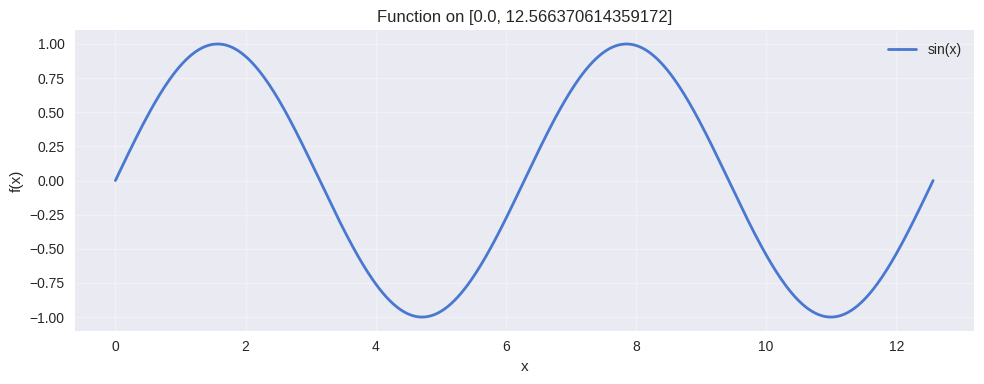

  Plotting Damped sine...


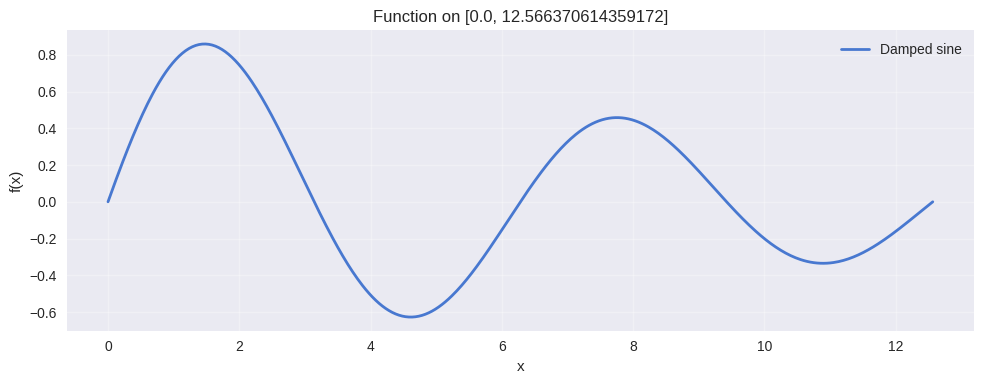

  Plotting Modulated sine...


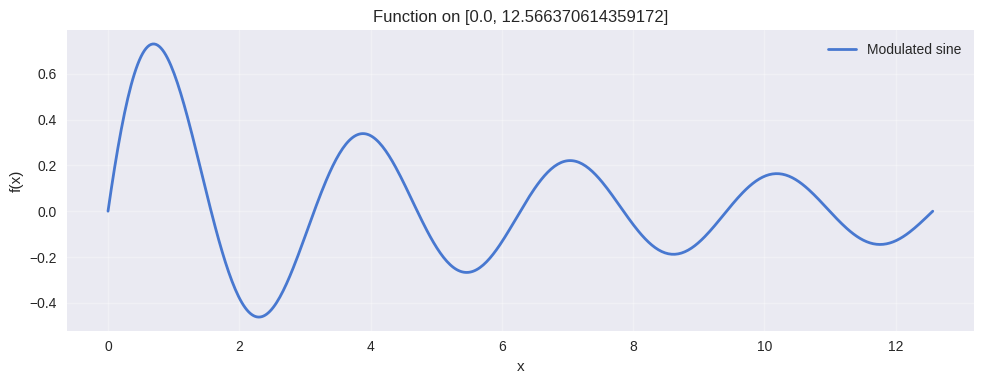

In [75]:
# Create interesting functions
domain = IntervalDomain(0, 4*np.pi, boundary_type='closed')

functions = [
    Function(domain, evaluate_callable=lambda x: np.sin(x), name="sin(x)"),
    Function(domain, evaluate_callable=lambda x: np.sin(x) * np.exp(-0.1*x), name="Damped sine"),
    Function(domain, evaluate_callable=lambda x: np.sin(2*x) / (1 + 0.5*x), name="Modulated sine"),
]

# Plot each individually using the built-in method
print("Using built-in plot() method:")
for func in functions:
    print(f"  Plotting {func.name}...")
    func.plot(n_points=500, figsize=(10, 4))
    plt.show()

## 8. Copying Functions

Functions can be copied to create independent instances.

### Core API Usage:

In [76]:
# Create a function
domain = IntervalDomain(0, 1, boundary_type='closed')
f = Function(domain, evaluate_callable=lambda x: x**2, name="original")

# Create a copy
f_copy = f.copy()

# Modify the copy's name
f_copy.name = "copy"

# Original is unchanged
print(f"Original: {f.name}")
print(f"Copy: {f_copy.name}")

Original: original
Copy: copy


## 9. Summary

The `Function` class in `intervalinf` provides a powerful and flexible way to work with functions on interval domains:

### Key Features:

1. **Standalone mode**: Create functions without needing a function space
   ```python
   f = Function(domain, evaluate_callable=lambda x: x**2)
   ```

2. **Simple evaluation**: Call functions like regular Python callables
   ```python
   y = f(x)  # Works for scalars and arrays
   ```

3. **Integration**: Built-in numerical integration with multiple methods
   ```python
   result = f.integrate(method='simpson')
   result_weighted = f.integrate(weight=lambda x: np.exp(-x))
   ```

4. **Compact support**: Specify regions where function is nonzero
   ```python
   f = Function(domain, evaluate_callable=..., support=(a, b))
   ```

5. **Function arithmetic**: Combine functions with +, -, ×, scalar operations
   ```python
   h = 2*f + g - 1
   ```

6. **Easy plotting**: Built-in visualization method
   ```python
   f.plot()
   ```

### What's Next:

- **Function Spaces**: See the next notebook for working with Lebesgue and Sobolev spaces
- **Basis Representations**: Learn about coefficient-based functions in Hilbert spaces
- **Operators**: Explore differential operators and spectral methods

The standalone function mode provides a clean, simple API for mathematical computations without the overhead of function space machinery when you don't need it!